In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import torch 
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
import copy
import mytools
import os, random


# Print and store device being used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


# Define important parameters

In [58]:
# Number of class in invariant mass used by the adversary
Num_classes = 10
# Hyper-parameter for adversarial training of the classifier
lambda_ = 10.0

run = 2


def seed_everything(seed: int = 0):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(int(run))

# Load and setup the data

In [59]:
# Read tritrig, wab, phiKK, and data files
df_tritrig = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_tritrig_limited.pk')
df_tritrig['PhiKK'] = 0.0
df_phiKK = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_phiKK_limited.pk')
df_phiKK['PhiKK'] = 1.0
df_wab = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_wab_limited.pk')
df_wab['PhiKK'] = 0.0 # Add label


print("tritrig: ", len(df_tritrig))
print("phiKK: ", len(df_phiKK))
print("wab: ", len(df_wab))


tritrig:  120739
phiKK:  4086
wab:  6596


In [60]:
# Make Training set with 20000 tritrig, 4000 phiKK, 4000 wab
tritrig_train = df_tritrig[0:20000]
wab_train = df_wab[0:3000]
phiKK_train = df_phiKK[0:3000]

# Combine and shuffle all training data
df_train = pd.concat([tritrig_train, phiKK_train, wab_train], ignore_index=True, sort=False)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)

# Get edges in invariant mass classes for one-hot encoding
# To be used for adverserial labels
# The edges are chosen such that each bin has equal number of background events
one_hot_edges = mytools.get_one_hot_edges(mytools.get_InvM( pd.concat([df_tritrig, df_wab], ignore_index=True, sort=False) ), n_bins=Num_classes)

# Split the training data into training and validation sets
df_train, df_val = train_test_split(df_train, test_size=0.33, random_state=42)

# Make X and y for training and validation sets
# the adverserial network has its own labels
X_train = df_train.drop(columns=['PhiKK'])
y_train = df_train['PhiKK']
y_adv_train = mytools.get_adv_labels( mytools.get_InvM(df_train), one_hot_edges)
X_val = df_val.drop(columns=['PhiKK'])
y_val = df_val['PhiKK']
y_adv_val = mytools.get_adv_labels( mytools.get_InvM(df_val), one_hot_edges)

# Make testing set with remaining events
tritrig_test = df_tritrig[20000:]
tritrig_test['type']= 'tritrig'
wab_test = df_wab[3000:]
wab_test['type']= 'wab'
phiKK_test = df_phiKK[3000:]
phiKK_test['type']= 'phiKK'

df_test = pd.concat([tritrig_test, phiKK_test,wab_test], ignore_index=True, sort=False)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True) # Now shuffle the combined dataframe

X_test = df_test.drop(columns=['PhiKK','type'])
y_test = df_test['PhiKK']
y_adv_test = mytools.get_adv_labels( mytools.get_InvM(df_test), one_hot_edges)

df_test["InvM"] = mytools.get_InvM(df_test) 



/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_57032/1157922432.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tritrig_test['type']= 'tritrig'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_57032/1157922432.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wab_test['type']= 'wab'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_57032/1157922432.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [61]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import joblib

# Replace -9999 sentinel values (missing electron Ecal cluster) with NaN
# so they don't corrupt the scaler statistics
SENTINEL_COLS = ['ele_Ecal_x', 'ele_Ecal_y', 'ele_Ecal_z']
for df in [X_train, X_val, X_test]:
    df[SENTINEL_COLS] = df[SENTINEL_COLS].replace(-9999.0, np.nan)

# Impute NaN with training-set column means, then standardize
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler()),
])

X_train = pd.DataFrame(pipeline.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_val   = pd.DataFrame(pipeline.transform(X_val),       columns=X_val.columns,   index=X_val.index)
X_test  = pd.DataFrame(pipeline.transform(X_test),      columns=X_test.columns,  index=X_test.index)

# Save the pipeline so it can be applied consistently during inference
joblib.dump(pipeline, "/Users/mghrear/data/ML_data/patch/scaler_2021_v9_pass5_run"+str(run)+"_limited.pkl")
print(f"Standardized {X_train.shape[1]} features using training-set statistics.")

Standardized 14 features using training-set statistics.


## Setup dataloaders

In [62]:
bsize = 2000

# Convert to tensor dataset and dataloader
train_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1)  )
train_loader = DataLoader(train_dataset, batch_size=bsize, shuffle=True)

val_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1)  )
val_loader = DataLoader(val_dataset, batch_size=bsize, shuffle=True)

test_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy().astype(np.float32)))
test_loader = DataLoader(test_dataset, batch_size=bsize, shuffle=False)


## Initialize model, objective function, and optimizer

In [63]:
clas = mytools.Classifier(in_features=X_train.shape[1]).to(device)
criterion_clas = nn.BCEWithLogitsLoss()
optimizer_clas = optim.Adam(clas.parameters(), lr=1e-2)
scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=1.0)


## Pre-train the classifier

In [64]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored
patience = 10

Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_clas(train_loader, clas, criterion_clas, optimizer_clas, scheduler_clas, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_clas(val_loader, clas, criterion_clas, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_classifier = copy.deepcopy(clas)
    
    if len(Validation_losses) > patience:
        if np.sum((Validation_losses[-1*np.arange(patience)-1] - Validation_losses[-1*np.arange(patience)-2]) < 0) == 0:
            print("Stopping early!")
            break
            
print("Done!")

Epoch 1
-------------------------------
Training loss: 0.333303
Validation loss: 0.444729 

Epoch 2
-------------------------------
Training loss: 0.078196
Validation loss: 0.123831 

Epoch 3
-------------------------------
Training loss: 0.039385
Validation loss: 0.069503 

Epoch 4
-------------------------------
Training loss: 0.031707
Validation loss: 0.022254 

Epoch 5
-------------------------------
Training loss: 0.023218
Validation loss: 0.021820 

Epoch 6
-------------------------------
Training loss: 0.021845
Validation loss: 0.024137 

Epoch 7
-------------------------------
Training loss: 0.020000
Validation loss: 0.023922 

Epoch 8
-------------------------------
Training loss: 0.018934
Validation loss: 0.029586 

Epoch 9
-------------------------------
Training loss: 0.020153
Validation loss: 0.025240 

Epoch 10
-------------------------------
Training loss: 0.018713
Validation loss: 0.024105 

Epoch 11
-------------------------------
Training loss: 0.018019
Validation los

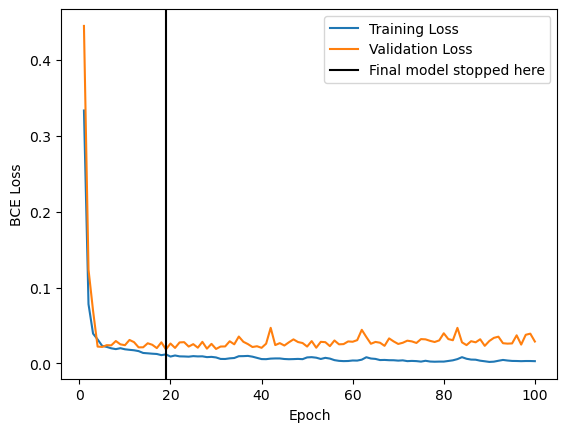

In [65]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
#plt.yscale('log')
plt.legend()

Test AUROC: 0.9955


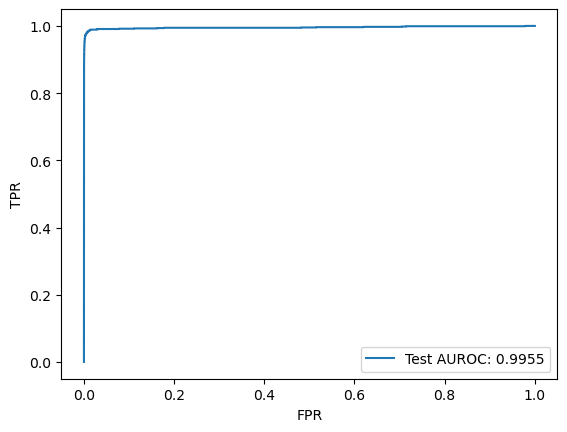

In [66]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

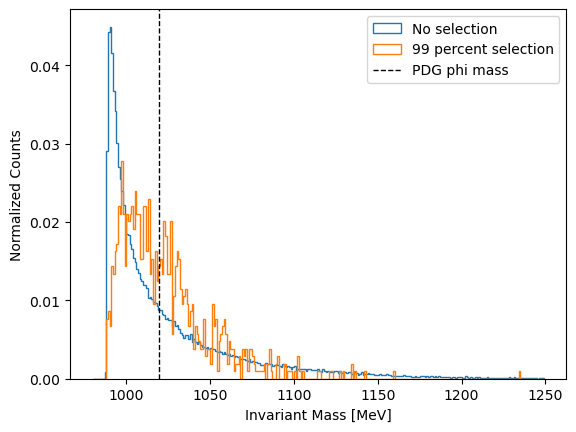

In [67]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],99)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [68]:
# Store the pretrained classifier labels
df_test["Class_pre"] = test_pred

# Save the pretrained classifier model
torch.save(final_classifier.state_dict(), "/Users/mghrear/data/ML_data/patch/pretrained_classifier_2021_v9_pass5_run"+str(run)+"_scaled.pt")


# Setup the adversary model

## Initialize model, objective function, and optimizer

In [69]:
adv = mytools.Adversary_small(n_classes=Num_classes).to(device)
criterion_adv = nn.CrossEntropyLoss(reduction='none')  # returns loss per sample so we can weight it
opt_adv = torch.optim.Adam(adv.parameters(), lr=1e-2)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(opt_adv, gamma=1.0)


## Setup dataloaders

In [70]:
# Convert to tensor dataset and dataloader

# the structure is: feature, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_adv_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_train), (torch.from_numpy(y_train.to_numpy().astype(np.float32))==0).float())
train_adv_loader = DataLoader(train_adv_dataset, batch_size=bsize, shuffle=True)

val_adv_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_val), (torch.from_numpy(y_val.to_numpy().astype(np.float32))==0).float() )
val_adv_loader = DataLoader(val_adv_dataset, batch_size=bsize, shuffle=True)

# Weights are not relavent for testing
test_adv_dataset = TensorDataset(torch.from_numpy(X_test.to_numpy() .astype(np.float32))  , torch.from_numpy(y_adv_test))
test_adv_loader = DataLoader(test_adv_dataset, batch_size=bsize, shuffle=True)

## Pre-train the adversary leaving classifier weights fixed

In [71]:
# Implement early stopping in training loop
# Stop if validation loss has not decreased for the last [patience] epochs
# The model with the lowest loss is stored


Training_losses = np.array([])
Validation_losses = np.array([])

epochs = 100
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    Training_losses = np.append(Training_losses, mytools.train_adv(train_adv_loader, final_classifier, adv, criterion_adv, opt_adv, scheduler_adv, device))
    Validation_losses = np.append(Validation_losses, mytools.validate_adv(val_adv_loader, final_classifier, adv, criterion_adv, device))
    
    # Keep a running copy of the model with the lowest loss
    if Validation_losses[-1] == np.min(Validation_losses):
        final_adv = copy.deepcopy(adv)

print("Done!")

Epoch 1
-------------------------------
Training loss: 2.884009
Validation loss: 2.618557 

Epoch 2
-------------------------------
Training loss: 2.479589
Validation loss: 2.422090 

Epoch 3
-------------------------------
Training loss: 2.372229
Validation loss: 2.339857 

Epoch 4
-------------------------------
Training loss: 2.324039
Validation loss: 2.320129 

Epoch 5
-------------------------------
Training loss: 2.311840
Validation loss: 2.316030 

Epoch 6
-------------------------------
Training loss: 2.295824
Validation loss: 2.316791 

Epoch 7
-------------------------------
Training loss: 2.288403
Validation loss: 2.302649 

Epoch 8
-------------------------------
Training loss: 2.284466
Validation loss: 2.309508 

Epoch 9
-------------------------------
Training loss: 2.285009
Validation loss: 2.301689 

Epoch 10
-------------------------------
Training loss: 2.285503
Validation loss: 2.298421 

Epoch 11
-------------------------------
Training loss: 2.285556
Validation los

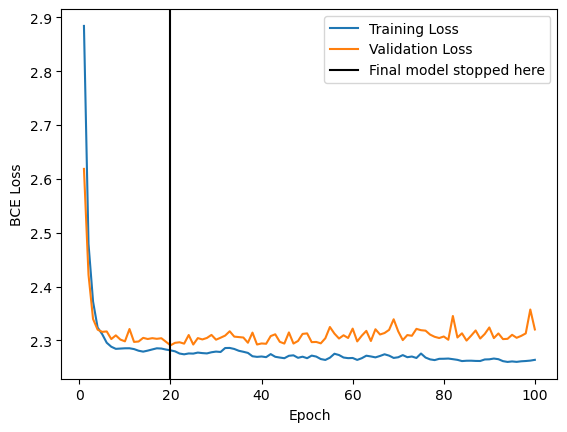

In [72]:
# Plot Training and Validation Loss
# Indicate where the final model stopped training

best_epoch = np.argmin(Validation_losses)+1

plt.plot(np.arange(len(Training_losses))+1,Training_losses,label="Training Loss")
plt.plot(np.arange(len(Validation_losses))+1,Validation_losses,label="Validation Loss")
plt.axvline(best_epoch,label="Final model stopped here",color='k')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()

# Train full adverserial neural network

# Setup dataloaders

In [73]:
# the structure is: feature, classifier label, adversary label, weight
# The wight is 1 for tritrig and wab, and 0 for phiKK, to prevent the adversary from learning on phiKK events

train_full_dataset = TensorDataset(torch.from_numpy(X_train.to_numpy().astype(np.float32))  , torch.from_numpy(y_train.to_numpy().astype(np.float32)).unsqueeze(1), torch.from_numpy(y_adv_train),  (torch.from_numpy(y_train.to_numpy().astype(np.float32))==0).float())
train_full_loader = DataLoader(train_full_dataset, batch_size=bsize, shuffle=True)

val_full_dataset = TensorDataset(torch.from_numpy(X_val.to_numpy().astype(np.float32))  , torch.from_numpy(y_val.to_numpy().astype(np.float32)).unsqueeze(1),  torch.from_numpy(y_adv_val),  (torch.from_numpy(y_val.to_numpy().astype(np.float32))==0).float())
val_full_loader = DataLoader(val_full_dataset, batch_size=bsize, shuffle=True)


## Define loss functions

In [74]:
BCE_loss = nn.BCEWithLogitsLoss()
CE_loss = nn.CrossEntropyLoss(reduction='none') # returns loss per sample so we can weight it

def full_loss(output_clas, output_adv, target_clas, target_adv, w, lambda_):

    loss1 = BCE_loss(output_clas, target_clas )  # classification loss
    sample_losses2 = CE_loss(output_adv, target_adv)  # adversarial losses, since we set reduction='none', this is now a vector of losses, one per sample in the batch

    # Weighted mean loss over non-zero weights
    nonzero = w > 0
    loss2 = (sample_losses2[nonzero] * w[nonzero]).sum() / w[nonzero].sum()

    loss = loss1 - lambda_*loss2

    return loss
    


## Setup optimizers

In [75]:
optimizer_clas = optim.Adam(final_classifier.parameters(), lr=1e-3,betas=(0.9, 0.999))
optimizer_adv = optim.Adam(final_adv.parameters(), lr=1e-2,betas=(0.9, 0.999))

scheduler_clas = torch.optim.lr_scheduler.ExponentialLR(optimizer_clas, gamma=0.999)
scheduler_adv = torch.optim.lr_scheduler.ExponentialLR(optimizer_adv, gamma=0.999)

## Adversarial training

Epoch 1
-------------------------------
Classifier training loss: -23.421438
Adversary training loss: 2.373279
Classifier validation loss: -22.850602
Adversary validation loss: 2.288665
Diff score: 1.001676


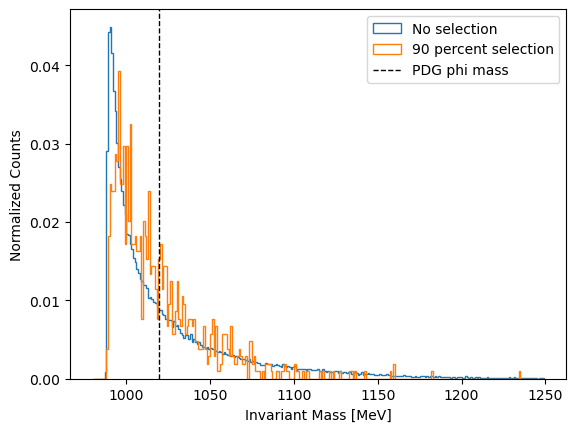

Epoch 2
-------------------------------
Classifier training loss: -22.675537
Adversary training loss: 2.275475
Classifier validation loss: -22.899817
Adversary validation loss: 2.296008
Diff score: 1.096717


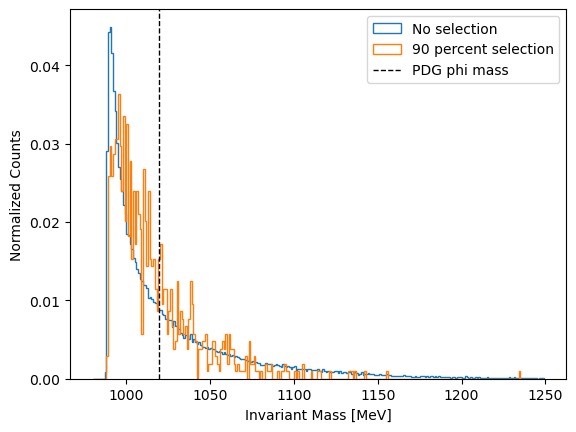

Epoch 3
-------------------------------
Classifier training loss: -22.872584
Adversary training loss: 2.295648
Classifier validation loss: -22.952725
Adversary validation loss: 2.299984
Diff score: 1.053833


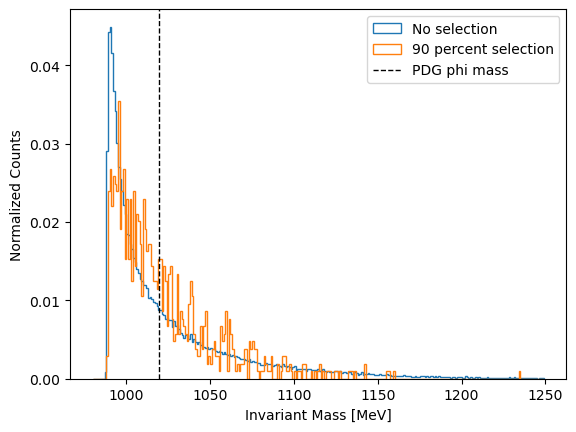

Epoch 4
-------------------------------
Classifier training loss: -22.985854
Adversary training loss: 2.304185
Classifier validation loss: -22.987741
Adversary validation loss: 2.302095
Diff score: 1.010046


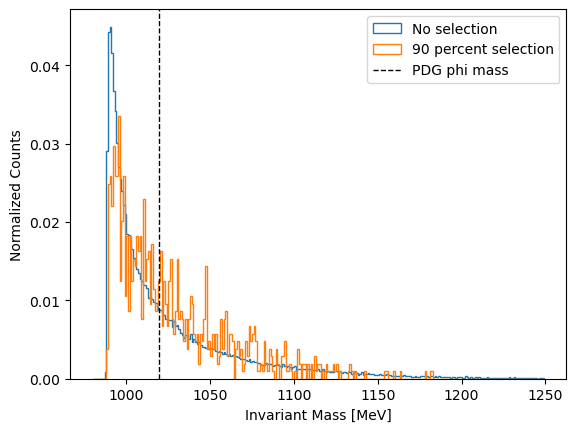

Epoch 5
-------------------------------
Classifier training loss: -22.986847
Adversary training loss: 2.304090
Classifier validation loss: -23.090999
Adversary validation loss: 2.311890
Diff score: 0.833050


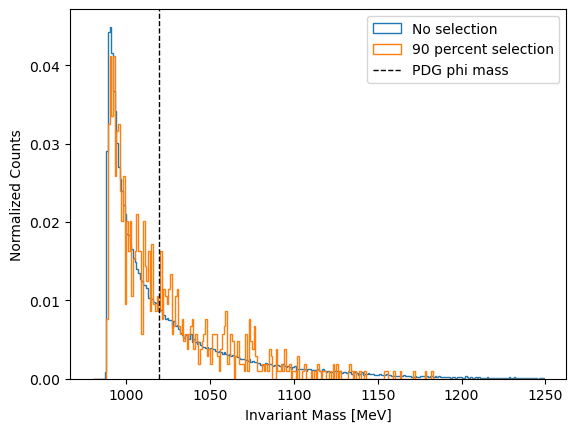

Epoch 6
-------------------------------
Classifier training loss: -23.032064
Adversary training loss: 2.304020
Classifier validation loss: -22.925045
Adversary validation loss: 2.295799
Diff score: 0.819013


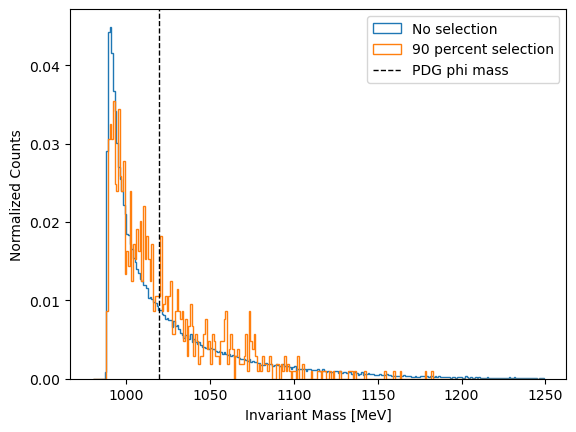

Epoch 7
-------------------------------
Classifier training loss: -22.860355
Adversary training loss: 2.288964
Classifier validation loss: -22.830568
Adversary validation loss: 2.286259
Diff score: 0.896795


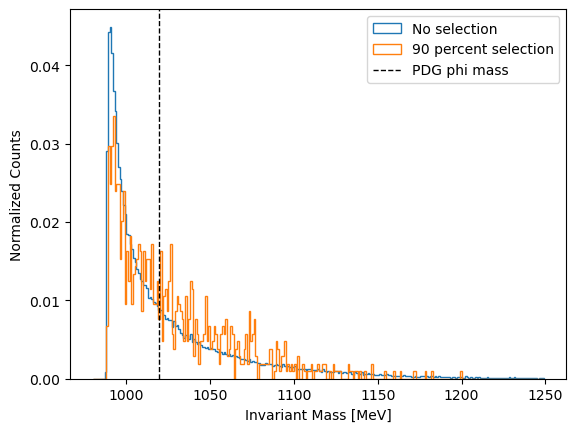

Epoch 8
-------------------------------
Classifier training loss: -22.873734
Adversary training loss: 2.292353
Classifier validation loss: -23.031168
Adversary validation loss: 2.306690
Diff score: 0.905233


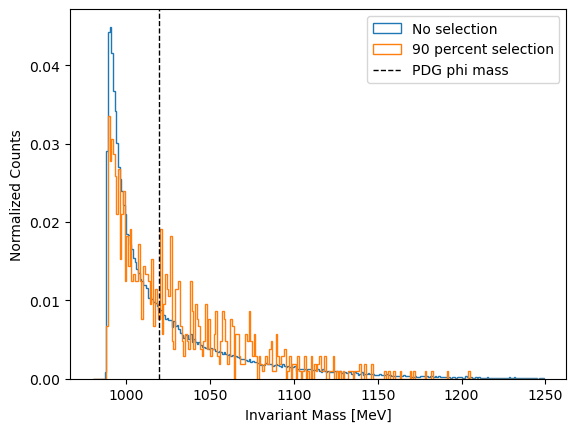

Epoch 9
-------------------------------
Classifier training loss: -22.961012
Adversary training loss: 2.299211
Classifier validation loss: -22.931890
Adversary validation loss: 2.296365
Diff score: 0.758913


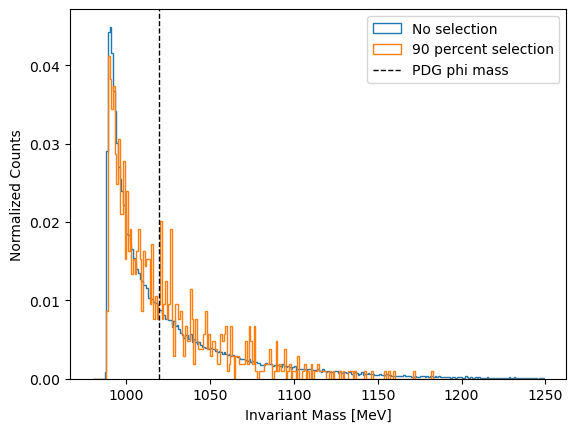

Epoch 10
-------------------------------
Classifier training loss: -22.961835
Adversary training loss: 2.300352
Classifier validation loss: -22.975470
Adversary validation loss: 2.300646
Diff score: 0.836156


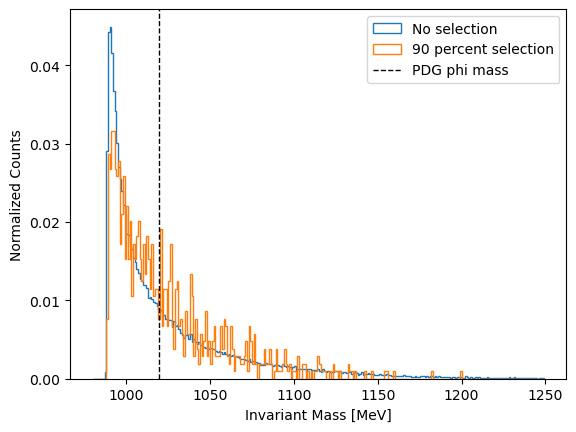

Epoch 11
-------------------------------
Classifier training loss: -22.952287
Adversary training loss: 2.298323
Classifier validation loss: -22.951300
Adversary validation loss: 2.298009
Diff score: 0.976304


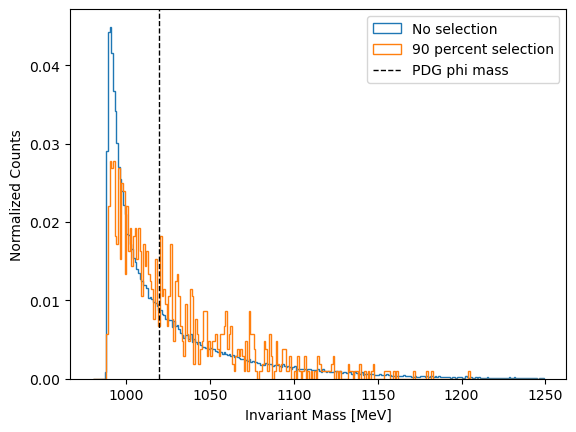

Epoch 12
-------------------------------
Classifier training loss: -22.953201
Adversary training loss: 2.299006
Classifier validation loss: -23.041232
Adversary validation loss: 2.306956
Diff score: 0.879199


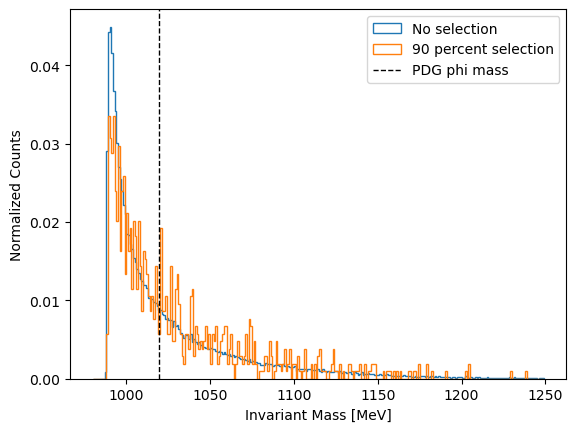

Epoch 13
-------------------------------
Classifier training loss: -23.001091
Adversary training loss: 2.303169
Classifier validation loss: -23.007264
Adversary validation loss: 2.304196
Diff score: 0.809307


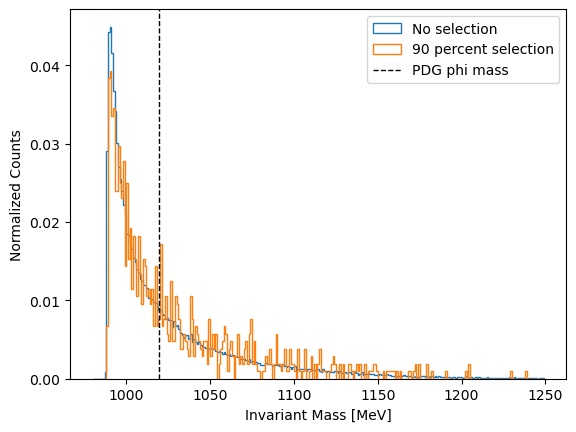

Epoch 14
-------------------------------
Classifier training loss: -22.960223
Adversary training loss: 2.299192
Classifier validation loss: -22.980553
Adversary validation loss: 2.300731
Diff score: 0.851136


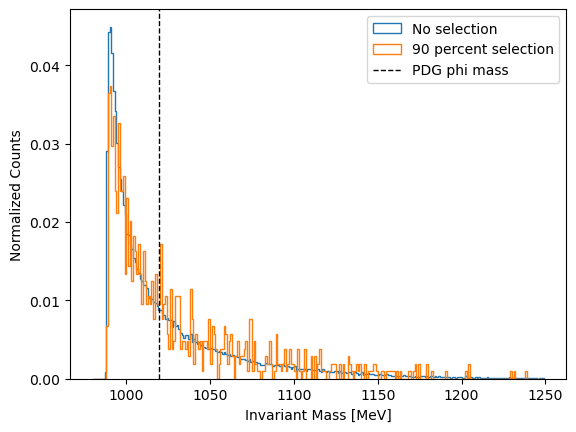

Epoch 15
-------------------------------
Classifier training loss: -22.960784
Adversary training loss: 2.299435
Classifier validation loss: -23.043695
Adversary validation loss: 2.306633
Diff score: 0.964719


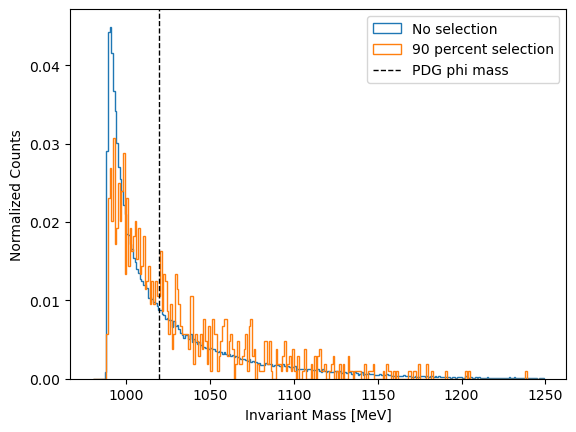

Epoch 16
-------------------------------
Classifier training loss: -22.980242
Adversary training loss: 2.300989
Classifier validation loss: -23.031263
Adversary validation loss: 2.305724
Diff score: 0.922105


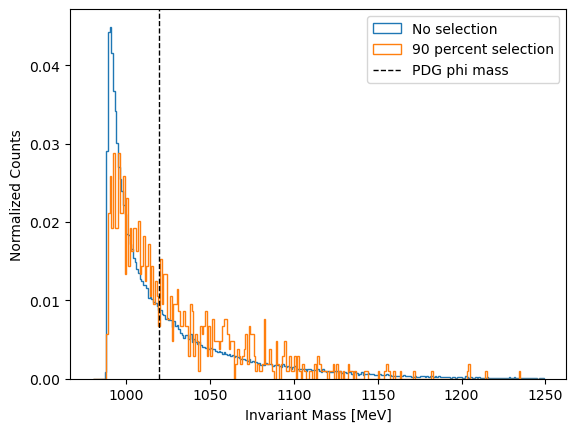

Epoch 17
-------------------------------
Classifier training loss: -22.982090
Adversary training loss: 2.301301
Classifier validation loss: -23.013386
Adversary validation loss: 2.303787
Diff score: 0.820952


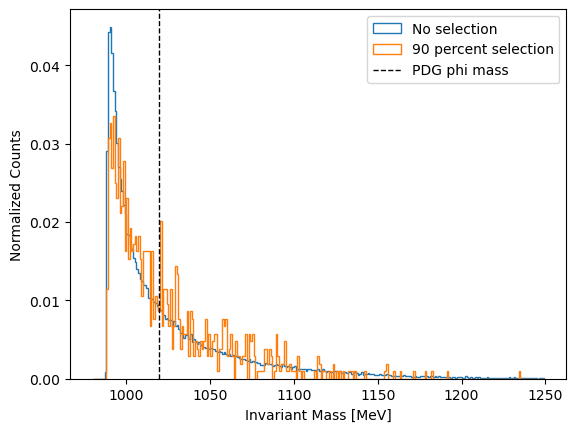

Epoch 18
-------------------------------
Classifier training loss: -22.987585
Adversary training loss: 2.301201
Classifier validation loss: -22.999740
Adversary validation loss: 2.302281
Diff score: 0.812177


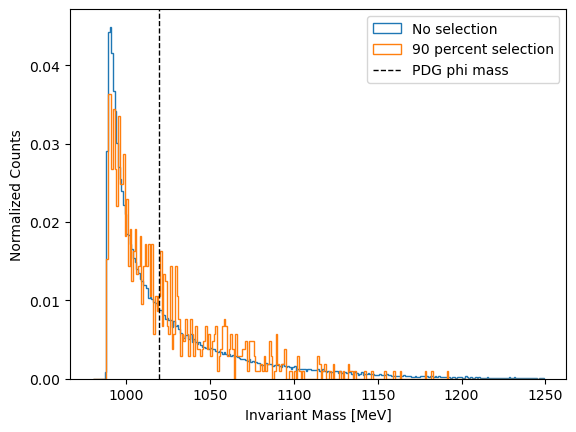

Epoch 19
-------------------------------
Classifier training loss: -22.986740
Adversary training loss: 2.301535
Classifier validation loss: -23.001907
Adversary validation loss: 2.302483
Diff score: 0.822586


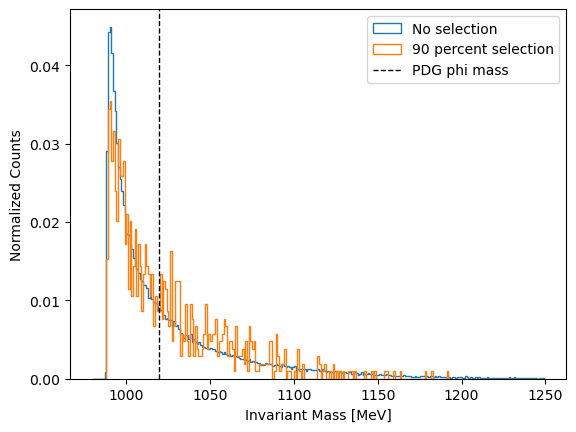

Epoch 20
-------------------------------
Classifier training loss: -22.988616
Adversary training loss: 2.301320
Classifier validation loss: -23.020870
Adversary validation loss: 2.304897
Diff score: 0.843379


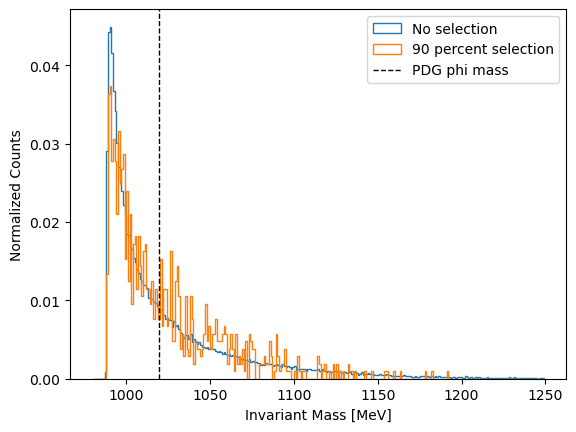

Epoch 21
-------------------------------
Classifier training loss: -22.983860
Adversary training loss: 2.301753
Classifier validation loss: -22.975456
Adversary validation loss: 2.300708
Diff score: 0.796220


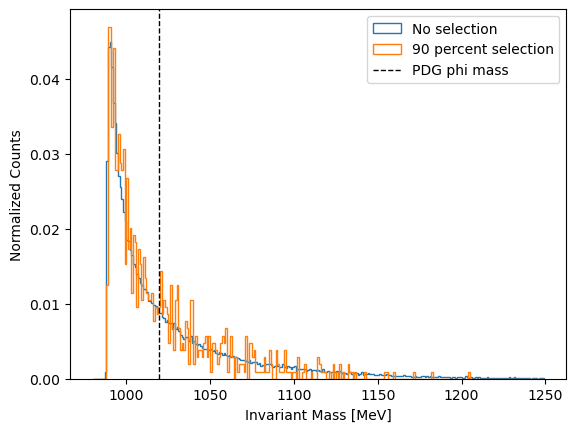

Epoch 22
-------------------------------
Classifier training loss: -22.974696
Adversary training loss: 2.300154
Classifier validation loss: -23.005198
Adversary validation loss: 2.302820
Diff score: 0.787660


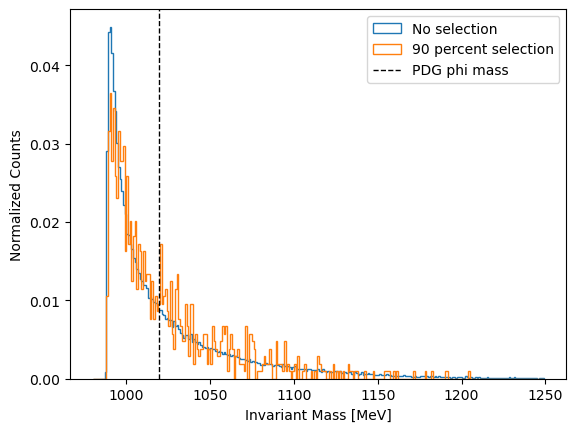

Epoch 23
-------------------------------
Classifier training loss: -22.987007
Adversary training loss: 2.301029
Classifier validation loss: -23.011675
Adversary validation loss: 2.303556
Diff score: 0.827232


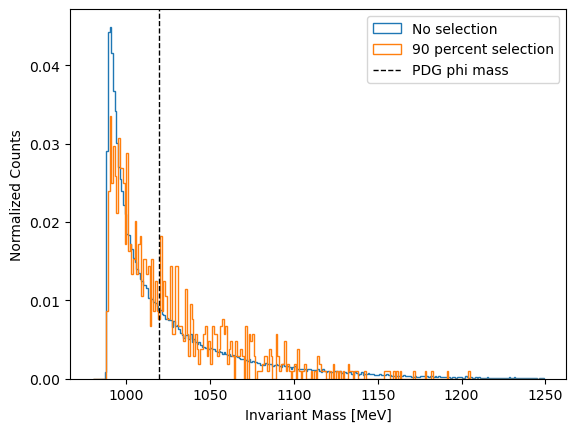

Epoch 24
-------------------------------
Classifier training loss: -22.990689
Adversary training loss: 2.301344
Classifier validation loss: -23.031590
Adversary validation loss: 2.305313
Diff score: 0.829036


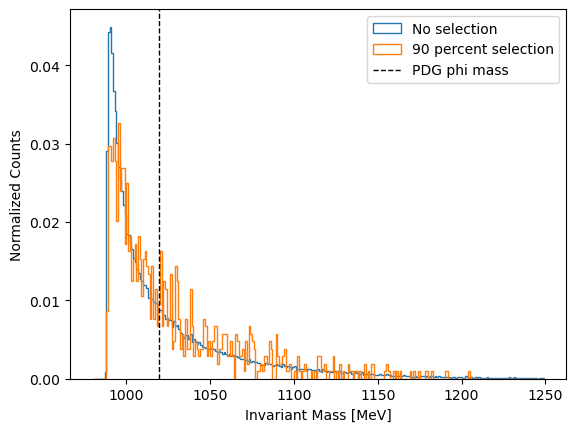

Epoch 25
-------------------------------
Classifier training loss: -22.981926
Adversary training loss: 2.300754
Classifier validation loss: -23.040314
Adversary validation loss: 2.306327
Diff score: 0.811950


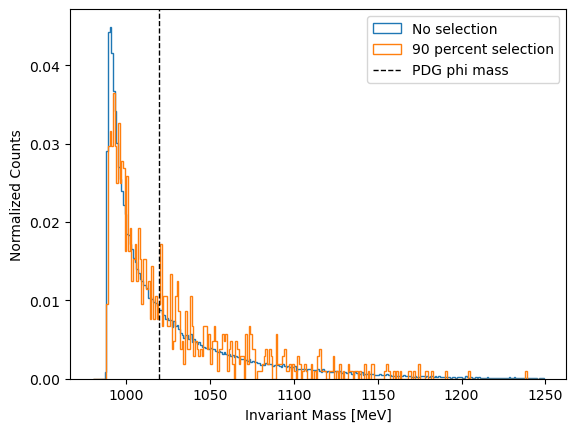

Epoch 26
-------------------------------
Classifier training loss: -22.996174
Adversary training loss: 2.302564
Classifier validation loss: -23.043533
Adversary validation loss: 2.306488
Diff score: 0.765421


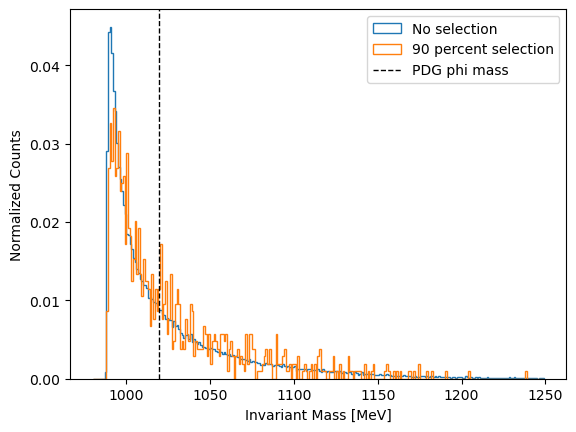

Epoch 27
-------------------------------
Classifier training loss: -22.990608
Adversary training loss: 2.301269
Classifier validation loss: -23.034885
Adversary validation loss: 2.306005
Diff score: 0.789614


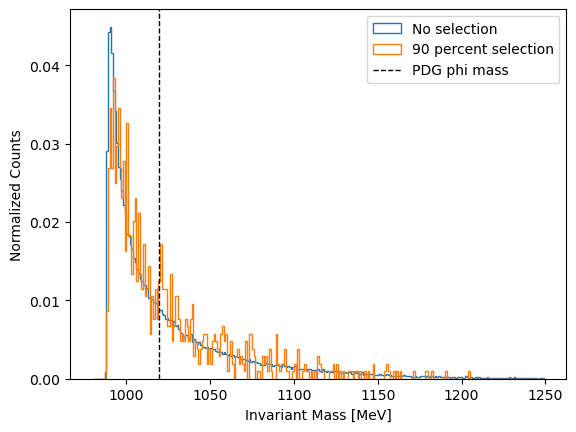

Epoch 28
-------------------------------
Classifier training loss: -22.988924
Adversary training loss: 2.300969
Classifier validation loss: -23.011629
Adversary validation loss: 2.303938
Diff score: 0.796368


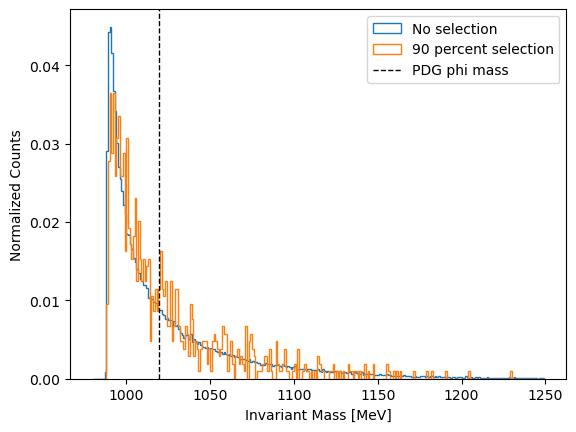

Epoch 29
-------------------------------
Classifier training loss: -22.991587
Adversary training loss: 2.301190
Classifier validation loss: -23.015678
Adversary validation loss: 2.303868
Diff score: 0.820297


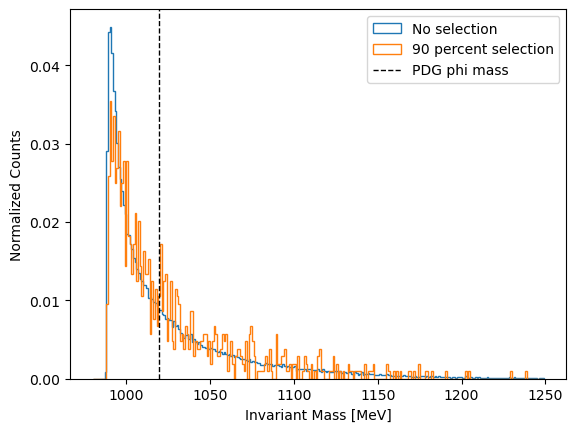

Epoch 30
-------------------------------
Classifier training loss: -22.991598
Adversary training loss: 2.301726
Classifier validation loss: -23.022005
Adversary validation loss: 2.304467
Diff score: 0.782130


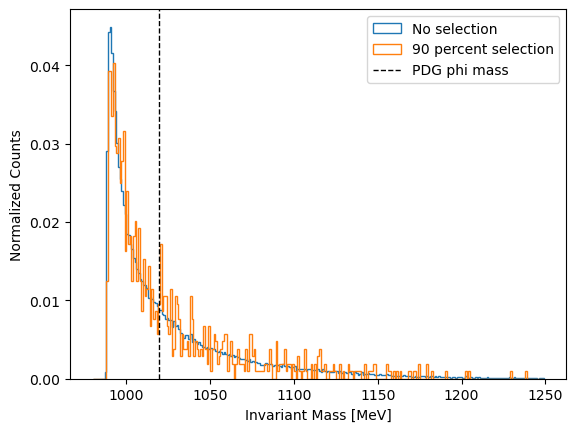

Epoch 31
-------------------------------
Classifier training loss: -22.997282
Adversary training loss: 2.300595
Classifier validation loss: -22.986108
Adversary validation loss: 2.300781
Diff score: 0.810080


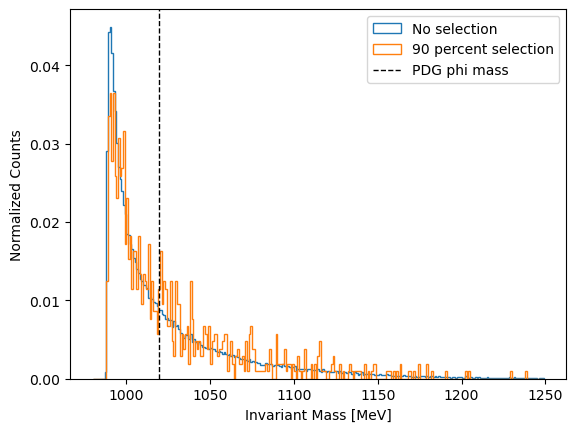

Epoch 32
-------------------------------
Classifier training loss: -22.997514
Adversary training loss: 2.301700
Classifier validation loss: -23.085212
Adversary validation loss: 2.310738
Diff score: 0.859848


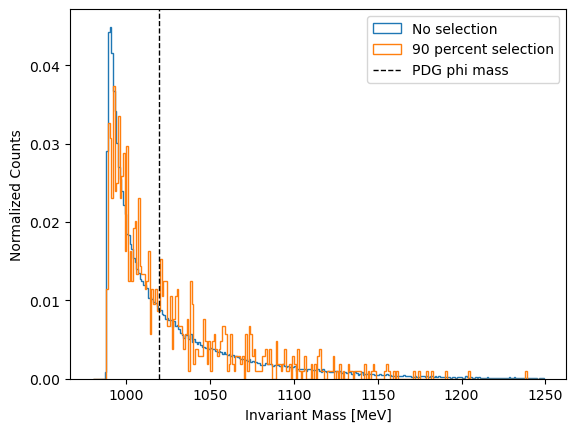

Epoch 33
-------------------------------
Classifier training loss: -22.993529
Adversary training loss: 2.300925
Classifier validation loss: -22.995631
Adversary validation loss: 2.301952
Diff score: 0.874551


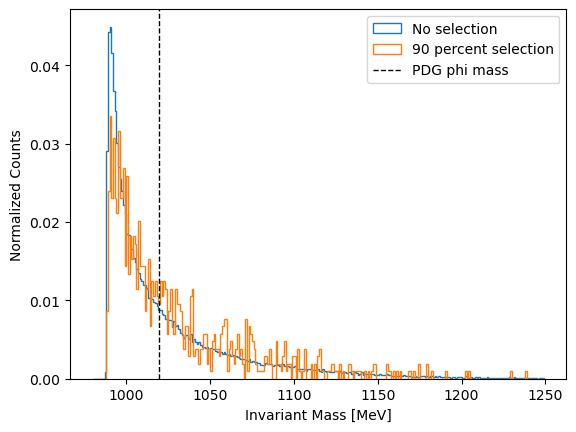

Epoch 34
-------------------------------
Classifier training loss: -22.992402
Adversary training loss: 2.301647
Classifier validation loss: -23.004555
Adversary validation loss: 2.302693
Diff score: 0.853084


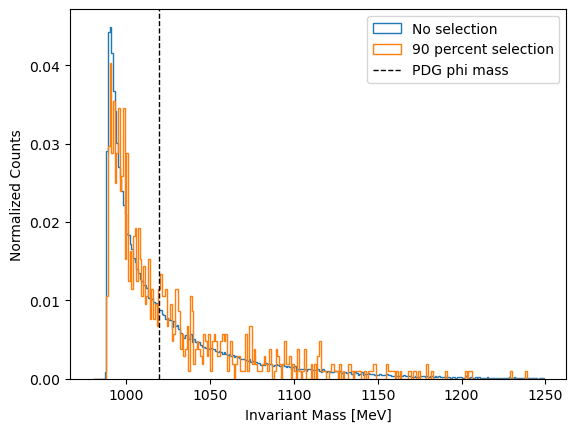

Epoch 35
-------------------------------
Classifier training loss: -22.995517
Adversary training loss: 2.301672
Classifier validation loss: -23.035217
Adversary validation loss: 2.305716
Diff score: 0.823261


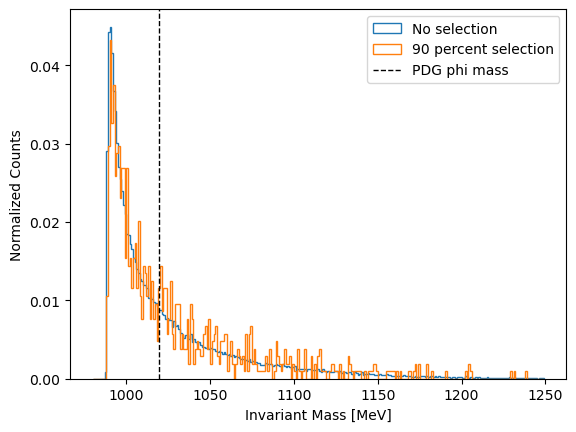

Epoch 36
-------------------------------
Classifier training loss: -22.997811
Adversary training loss: 2.301367
Classifier validation loss: -23.030333
Adversary validation loss: 2.305572
Diff score: 0.854253


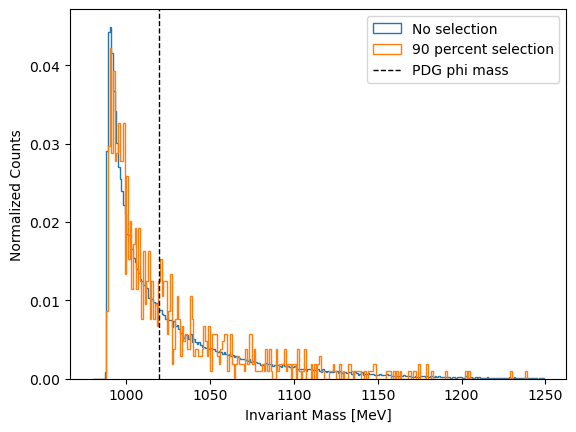

Epoch 37
-------------------------------
Classifier training loss: -22.989488
Adversary training loss: 2.301454
Classifier validation loss: -23.022269
Adversary validation loss: 2.304487
Diff score: 0.783109


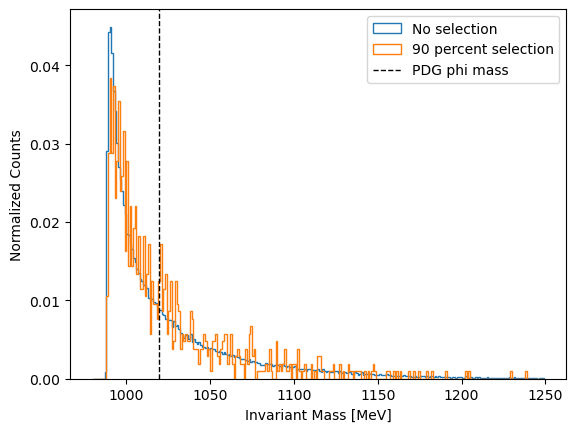

Epoch 38
-------------------------------
Classifier training loss: -22.994697
Adversary training loss: 2.301425
Classifier validation loss: -23.013845
Adversary validation loss: 2.303671
Diff score: 0.787411


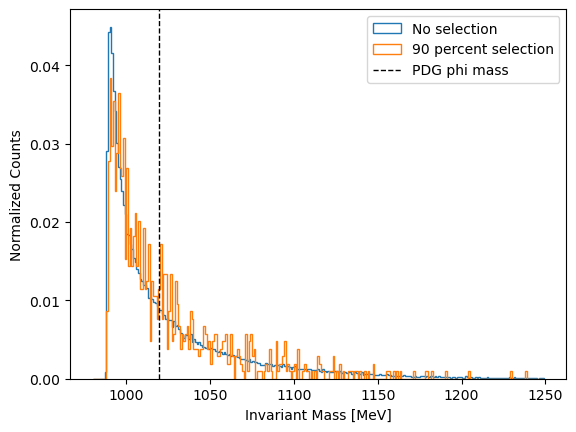

Epoch 39
-------------------------------
Classifier training loss: -22.991571
Adversary training loss: 2.300945
Classifier validation loss: -23.062385
Adversary validation loss: 2.308599
Diff score: 0.765396


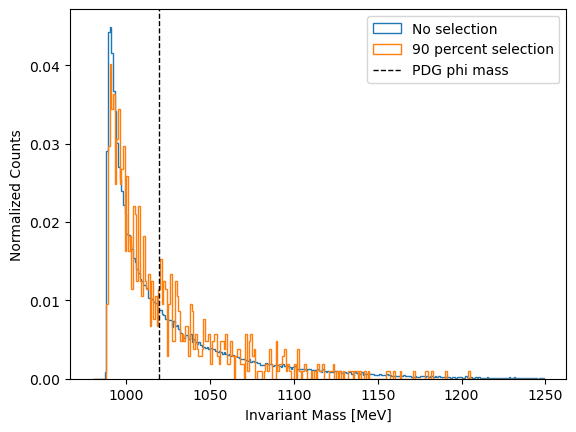

Epoch 40
-------------------------------
Classifier training loss: -22.996173
Adversary training loss: 2.301155
Classifier validation loss: -23.021664
Adversary validation loss: 2.304523
Diff score: 0.849225


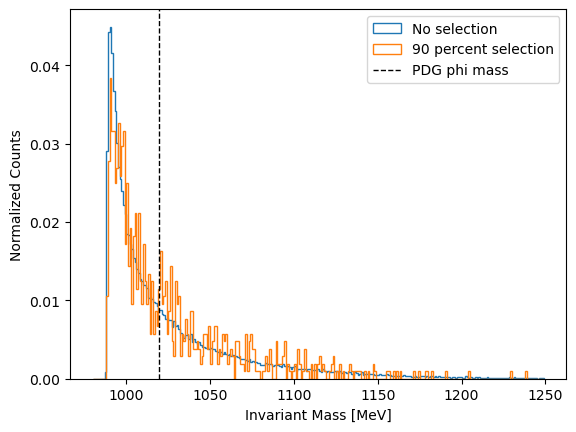

Epoch 41
-------------------------------
Classifier training loss: -22.993275
Adversary training loss: 2.300939
Classifier validation loss: -23.011871
Adversary validation loss: 2.303557
Diff score: 0.807364


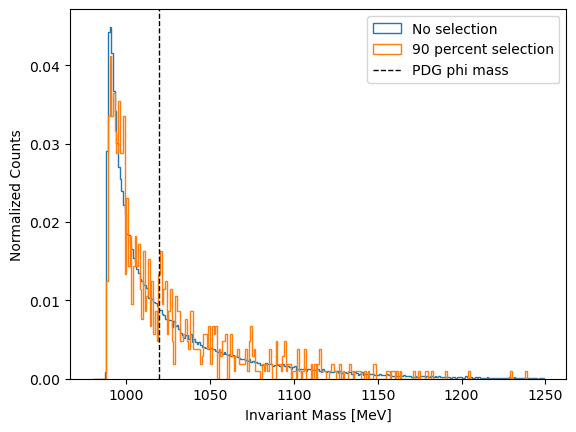

Epoch 42
-------------------------------
Classifier training loss: -22.994624
Adversary training loss: 2.302105
Classifier validation loss: -23.008614
Adversary validation loss: 2.303548
Diff score: 0.872791


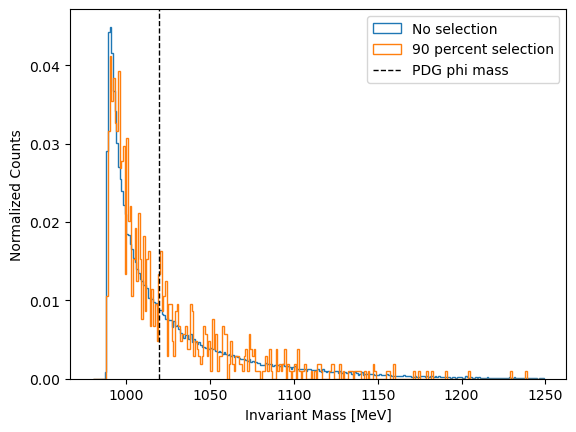

Epoch 43
-------------------------------
Classifier training loss: -22.993331
Adversary training loss: 2.301336
Classifier validation loss: -23.010498
Adversary validation loss: 2.303376
Diff score: 0.865720


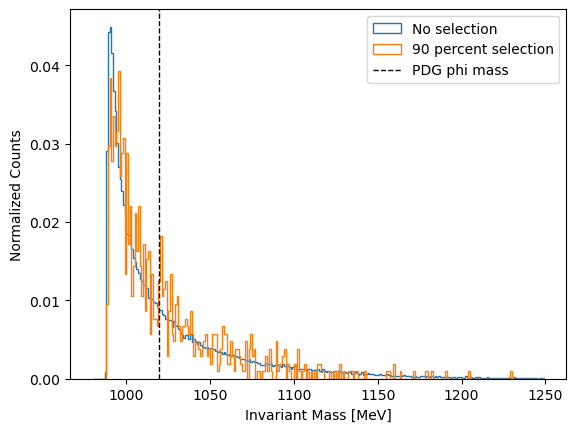

Epoch 44
-------------------------------
Classifier training loss: -22.998513
Adversary training loss: 2.301936
Classifier validation loss: -23.020667
Adversary validation loss: 2.304330
Diff score: 0.771098


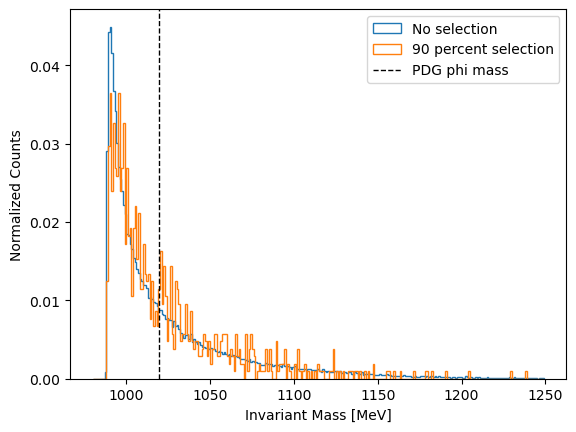

Epoch 45
-------------------------------
Classifier training loss: -22.988373
Adversary training loss: 2.300912
Classifier validation loss: -23.064852
Adversary validation loss: 2.308860
Diff score: 0.859032


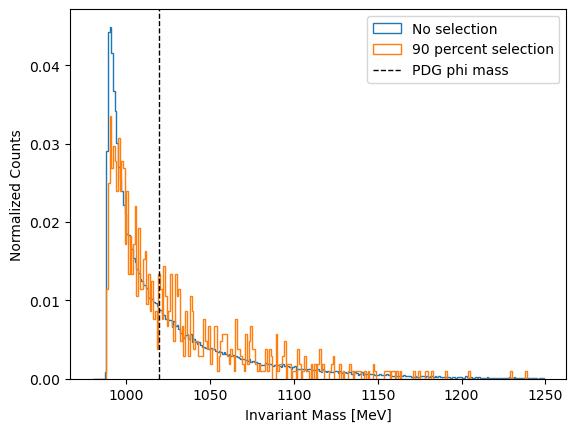

Epoch 46
-------------------------------
Classifier training loss: -22.998260
Adversary training loss: 2.301454
Classifier validation loss: -23.067595
Adversary validation loss: 2.309021
Diff score: 0.813542


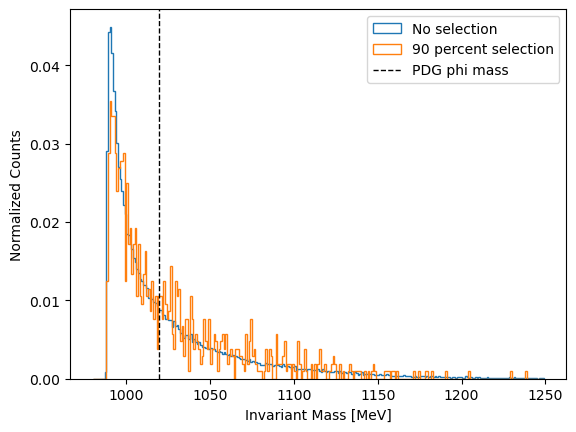

Epoch 47
-------------------------------
Classifier training loss: -22.985964
Adversary training loss: 2.300471
Classifier validation loss: -23.070433
Adversary validation loss: 2.309080
Diff score: 0.784991


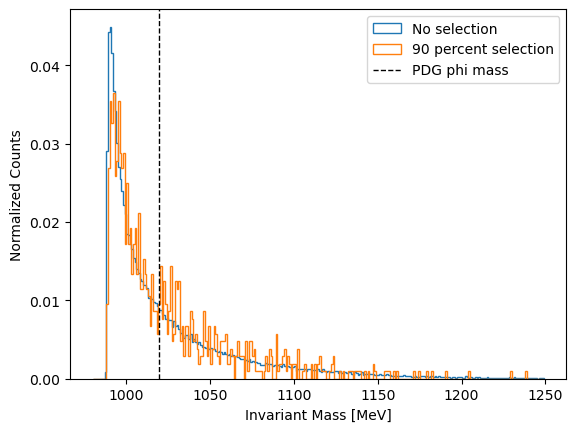

Epoch 48
-------------------------------
Classifier training loss: -23.000702
Adversary training loss: 2.301914
Classifier validation loss: -23.036932
Adversary validation loss: 2.305664
Diff score: 0.805824


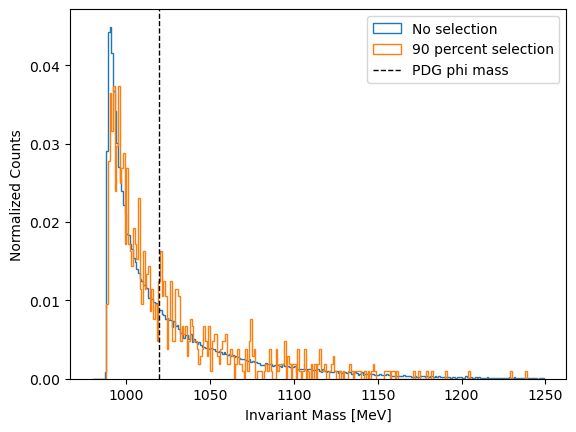

Epoch 49
-------------------------------
Classifier training loss: -23.000583
Adversary training loss: 2.301548
Classifier validation loss: -23.035561
Adversary validation loss: 2.305650
Diff score: 0.909406


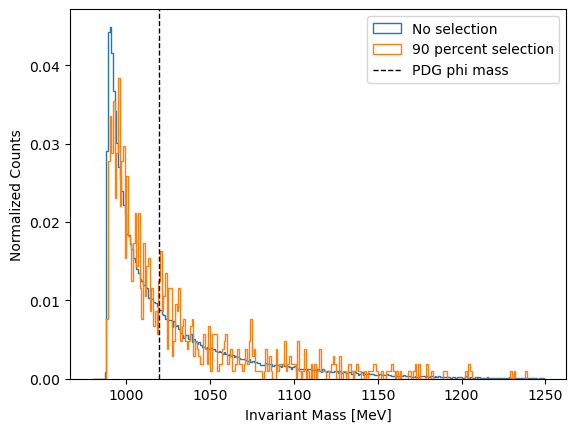

Epoch 50
-------------------------------
Classifier training loss: -23.004676
Adversary training loss: 2.302061
Classifier validation loss: -23.026429
Adversary validation loss: 2.304931
Diff score: 0.879055


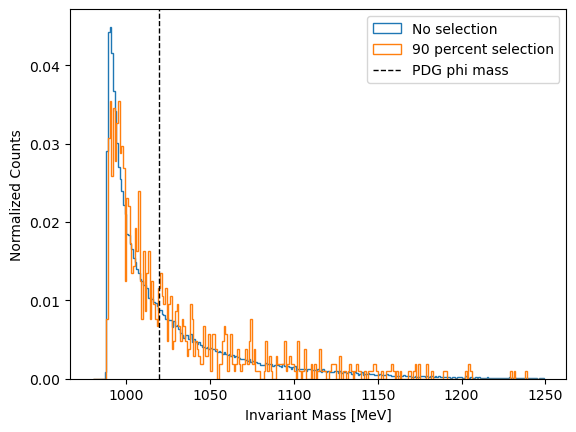

Done!


In [76]:


Training_losses_clas = np.array([])
Training_losses_adv = np.array([])
Validation_losses_clas = np.array([])
Validation_losses_adv = np.array([])
diff_scores = np.array([])


epochs = 50
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    
    # Train adversary and classifier
    E_clas_training_loss , E_adv_training_loss = mytools.train_full_orig(train_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, optimizer_clas, optimizer_adv, scheduler_clas, scheduler_adv, 8, device, grad_clip = False)
    Training_losses_clas = np.append(Training_losses_clas, E_clas_training_loss)
    Training_losses_adv = np.append(Training_losses_adv, E_adv_training_loss)

    # Get validation losses
    E_clas_val_loss, E_adv_val_loss = mytools.validate_full(val_full_loader, final_classifier, final_adv, full_loss, lambda_, criterion_adv, device)
    Validation_losses_clas = np.append(Validation_losses_clas, E_clas_val_loss)
    Validation_losses_adv = np.append(Validation_losses_adv, E_adv_val_loss)

    # Get the diff_score
    df_test["Class_adv"] = mytools.test_clas(test_loader, final_classifier, device)
    df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
    per = np.percentile(df_bkg['Class_adv'],99)
    df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
    x1 = 1000*df_bkg.InvM.values
    x2 = 1000*df_cut.InvM.values
    diff_scores = np.append(diff_scores, mytools.get_diff_score(x1,x2) )

    print(f"Diff score: {diff_scores[-1]:>7f}")

    plt.figure()
    plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
    plt.hist(1000*df_cut.InvM, bins=np.arange(980,1250,1), histtype='step', label= '90 percent selection', density=True)
    plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
    plt.xlabel('Invariant Mass [MeV]')
    plt.ylabel('Normalized Counts')
    plt.legend()
    plt.show()

    # Keep a running copy of the model with the lowest loss
    if diff_scores[-1] == np.min(diff_scores):
        final_clas_adv = copy.deepcopy(final_classifier)
        final_adv_adv = copy.deepcopy(final_adv)

            
print("Done!")

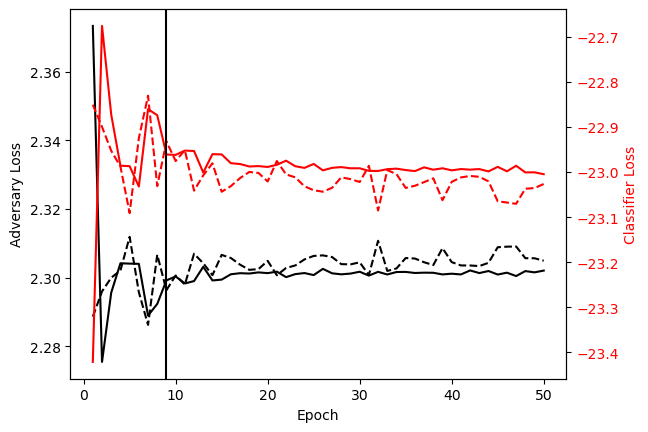

In [77]:
# Training Losses

fig, ax1 = plt.subplots()

best_epoch = np.argmin(diff_scores)+1



ax1.plot(np.arange(len(Training_losses_adv))+1, Training_losses_adv, 'k-', label='Training Adversary')
ax1.plot(np.arange(len(Validation_losses_adv))+1, Validation_losses_adv, 'k--', label='Validation Adversary')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Adversary Loss', color='k')
ax1.tick_params(axis='y', labelcolor='k')

ax2 = ax1.twinx()

ax2.plot(np.arange(len(Training_losses_clas))+1, Training_losses_clas, 'r-', label='Training Classifier')
ax2.plot(np.arange(len(Validation_losses_clas))+1, Validation_losses_clas, 'r--', label='Validation Classifier')
ax2.axvline(best_epoch,label="Final model stopped here",color='k')

ax2.set_ylabel('Classifier Loss', color='r')
ax2.tick_params(axis='y', labelcolor='r')



Text(0.5, 0, 'Epoch')

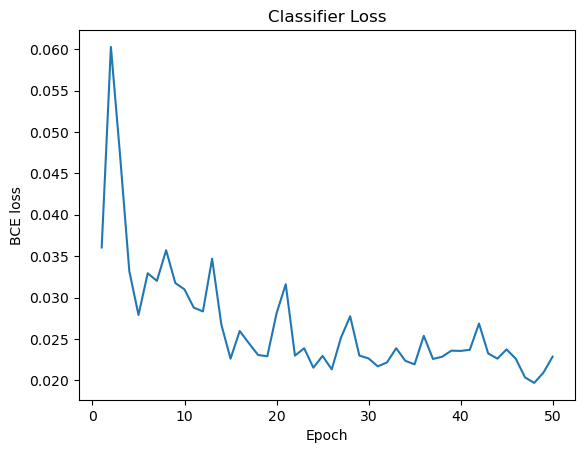

In [78]:
Validation_losses_clas+lambda_*Validation_losses_adv

plt.title("Classifier Loss")
plt.plot(np.arange(len(Training_losses_adv))+1, Validation_losses_clas+lambda_*Validation_losses_adv)
plt.ylabel("BCE loss")
plt.xlabel('Epoch')

## Test adversarially trained models

Test AUROC: 0.9945


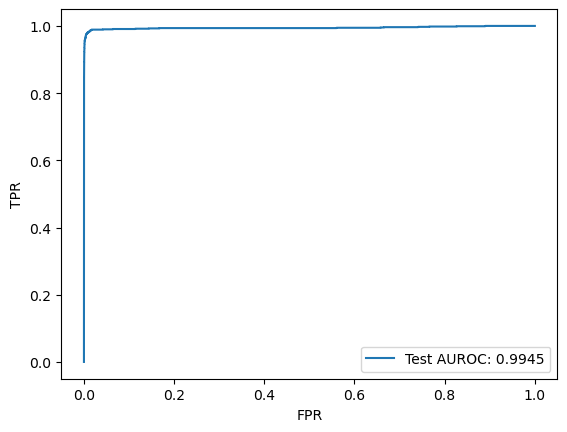

In [51]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_clas_adv, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

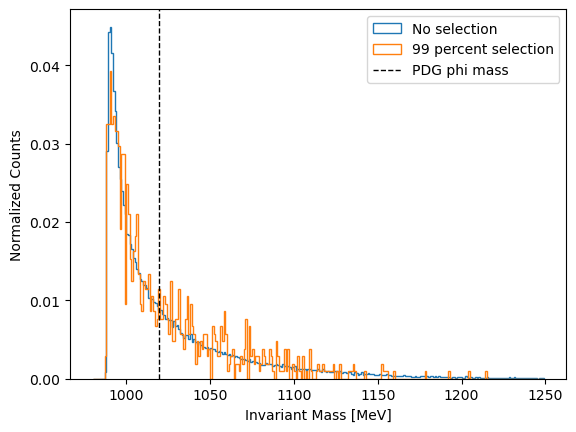

In [52]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],99)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [53]:

x1 = 1000* df_bkg.InvM.values
x2 = 1000*df_cut.InvM.values

N, edges = np.histogram(x1, bins=np.arange(980,1250,1), density=False)
M, edges = np.histogram(x2, bins=np.arange(980,1250,1), density=False)

N2 = N[(N > 0) & (M > 0)]
M2 = M[(N > 0) & (M > 0)]

diff_score = np.mean( np.abs( N2/np.sum(N) - M2/np.sum(M) ) / np.sqrt( ( np.sqrt(N2)/np.sum(N) )**2 + ( np.sqrt(M2)/np.sum(M) )**2 ) )

print(diff_score)

N = len(df_test.loc[ ((df_test.type == 'tritrig') | (df_test.type == 'wab')) & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per ) ] )
S = len(df_test.loc[ (df_test.type == 'phiKK') & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per )  ] )

print(S/N)

0.7022776943427026
5.41578947368421


Test AUROC: 0.9947


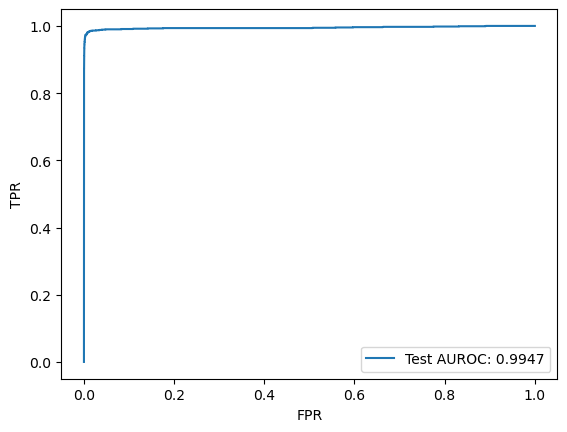

In [54]:
# Now test the pretrained model
test_pred = mytools.test_clas(test_loader, final_classifier, device)
test_pred=torch.sigmoid(torch.tensor(test_pred)).numpy()


fpr, tpr, thresholds = sklearn.metrics.roc_curve(y_test, test_pred, pos_label=1)
auc_test = sklearn.metrics.auc(fpr, tpr)
print(f'Test AUROC: {auc_test:0.4f}')

plt.plot(fpr, tpr, label=f'Test AUROC: {auc_test:0.4f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()

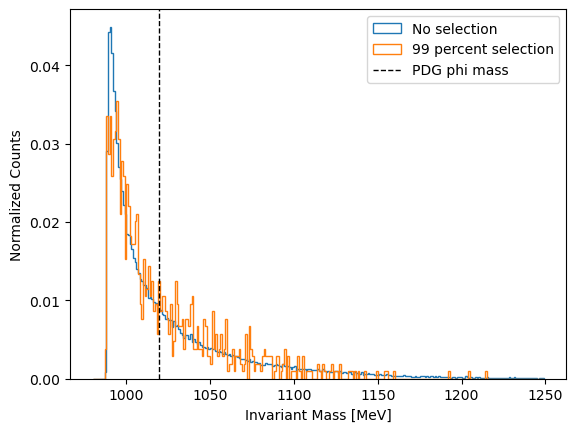

In [55]:
df_test["Class_adv"] = test_pred
df_bkg = df_test.loc[ (df_test.type == 'tritrig') | (df_test.type == 'wab')]
per = np.percentile(df_bkg['Class_adv'],99)
df_cut = df_bkg[df_bkg['Class_adv']>per].reset_index(drop=True)
x_vals = 1000*df_cut.InvM

plt.figure()
plt.hist(1000*df_bkg.InvM, bins=np.arange(980,1250,1), histtype='step', label='No selection', density=True)
plt.hist(x_vals, bins=np.arange(980,1250,1), histtype='step', label= '99 percent selection', density=True)
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG phi mass')
plt.xlabel('Invariant Mass [MeV]')
plt.ylabel('Normalized Counts')
plt.legend()

In [56]:

x1 = 1000* df_bkg.InvM.values
x2 = 1000*df_cut.InvM.values

N, edges = np.histogram(x1, bins=np.arange(980,1250,1), density=False)
M, edges = np.histogram(x2, bins=np.arange(980,1250,1), density=False)

N2 = N[(N > 0) & (M > 0)]
M2 = M[(N > 0) & (M > 0)]

diff_score = np.mean(np.abs(N2/np.sum(N)-M2/np.sum(M)) / (np.sqrt(N2)/np.sum(N) + np.sqrt(M2)/np.sum(M) ))

print(diff_score)

N = len(df_test.loc[ ((df_test.type == 'tritrig') | (df_test.type == 'wab')) & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per ) ] )
S = len(df_test.loc[ (df_test.type == 'phiKK') & (df_test.InvM < (1.019 + 0.01) )  & (df_test.InvM > (1.019 - 0.01) ) & ( df_test['Class_adv']>per )  ] )

print(S/N)

0.6721347697324166
5.25


In [57]:
# Save the adversarially trained models
torch.save(final_clas_adv.state_dict(), "/Users/mghrear/data/ML_data/patch/classifier_adv_2021_v9_pass5_run"+str(run)+"_scaled.pt")
torch.save(final_adv_adv.state_dict(), "/Users/mghrear/data/ML_data/patch/adversary_adv_2021_v9_pass5_run"+str(run)+"_scaled.pt")